# Laptop Price Prediction — Complete Machine Learning Project

## Objective
Build an end-to-end machine learning project to predict **Laptop Price** from laptop specifications.

### Important modeling decision
`Price` is a **continuous numeric target**, so this dataset is naturally a **regression problem**.

Therefore, the classification models/metrics in the supplied code (`accuracy`, `precision`, `recall`, `F1`, ROC-AUC) are not appropriate for predicting the exact price.

This project keeps the same overall workflow you requested:

**Clean Data → EDA → Data Analysis → ML Models → Model Comparison → Grid Search → Final Model**

For regression, the main metrics are:
- MAE
- MSE
- RMSE
- R²
- MAPE

An optional classification section at the end converts price into Low/Medium/High categories if you specifically need to use classification metrics.


In [7]:
# =========================
# Imports
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
    StackingRegressor
)

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load the Dataset


In [8]:
DATA_PATH = "laptopData.csv"

df = pd.read_csv(DATA_PATH)

print("Original shape:", df.shape)
display(df.head())
display(df.sample(5, random_state=42))


Original shape: (1303, 12)


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
479,479.0,Toshiba,Notebook,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.05kg,89084.16
1022,1022.0,HP,Notebook,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.11kg,61218.72
298,298.0,Lenovo,Notebook,15.6,Full HD 1920x1080,AMD A10-Series 9600P 2.4GHz,6GB,1TB HDD,AMD Radeon R5 430,Windows 10,2.4kg,26586.72
1265,1265.0,Lenovo,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,Nvidia GeForce GTX 960M,Windows 10,2.6kg,47898.72
774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Initial Data Inspection


In [9]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nStatistical summary:")
display(df.describe(include="all").T)


Shape: (1303, 12)

Data types:


,dtype
Unnamed: 0,float64
Company,object
TypeName,object
Inches,object
ScreenResolution,object
Cpu,object
Ram,object
Memory,object
Gpu,object
OpSys,object



Missing values:


,missing
Unnamed: 0,30
Company,30
TypeName,30
Inches,30
ScreenResolution,30
Cpu,30
Ram,30
Memory,30
Gpu,30
OpSys,30



Duplicate rows: 29

Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1273.0,NaN,NaN,NaN,652.674784,376.493027,0.0,327.0,652.0,980.0,1302.0
Company,1273,19,Lenovo,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TypeName,1273,6,Notebook,710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inches,1273,25,15.6,640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ScreenResolution,1273,40,Full HD 1920x1080,495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cpu,1273,118,Intel Core i5 7200U 2.5GHz,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ram,1273,10,8GB,601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Memory,1273,40,256GB SSD,401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gpu,1273,110,Intel HD Graphics 620,271,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OpSys,1273,9,Windows 10,1047,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning

The uploaded file contains **30 completely empty rows**. These are removed first.

The `Unnamed: 0` column is an exported index and has no predictive meaning, so it is removed.

`Ram` and `Weight` contain units such as `GB` and `kg`; these are converted to numeric values.

Several useful features are extracted from the raw specifications:
- RAM in GB
- Weight in kg
- CPU clock speed
- Screen width/height
- Total screen pixels
- Touchscreen flag
- IPS flag
- CPU brand
- GPU brand
- SSD/HDD/Flash/Hybrid storage sizes


In [10]:
# Remove completely empty rows
df_clean = df.dropna(how="all").copy()

# Remove duplicates
before_duplicates = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Remove exported index
df_clean = df_clean.drop(columns=["Unnamed: 0"], errors="ignore")

# Clean text columns
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Convert target
df_clean["Price"] = pd.to_numeric(df_clean["Price"], errors="coerce")

# Numeric extraction
df_clean["Inches"] = pd.to_numeric(df_clean["Inches"], errors="coerce")
df_clean["Ram_GB"] = df_clean["Ram"].str.extract(r"(\d+)").astype(float)
df_clean["Weight_kg"] = df_clean["Weight"].str.extract(r"([\d.]+)").astype(float)
df_clean["Cpu_GHz"] = df_clean["Cpu"].str.extract(r"([\d.]+)GHz").astype(float)

# Screen resolution
screen_parts = df_clean["ScreenResolution"].str.extract(r"(\d+)\s*x\s*(\d+)")
df_clean["Screen_Width"] = screen_parts[0].astype(float)
df_clean["Screen_Height"] = screen_parts[1].astype(float)
df_clean["Pixels"] = df_clean["Screen_Width"] * df_clean["Screen_Height"]

# Screen properties
df_clean["Touchscreen"] = df_clean["ScreenResolution"].str.contains(
    "Touchscreen", case=False, na=False
).astype(int)

df_clean["IPS"] = df_clean["ScreenResolution"].str.contains(
    "IPS", case=False, na=False
).astype(int)

# CPU/GPU brands
df_clean["CPU_Brand"] = df_clean["Cpu"].str.split().str[0]
df_clean["GPU_Brand"] = df_clean["Gpu"].str.split().str[0]

# Storage extraction
df_clean["Memory_SSD_GB"] = df_clean["Memory"].str.extract(
    r"(\d+)\s*GB\s*SSD", expand=False
).astype(float)

df_clean["Memory_HDD_GB"] = df_clean["Memory"].str.extract(
    r"(\d+)\s*GB\s*HDD", expand=False
).astype(float)

df_clean["Memory_Flash_GB"] = df_clean["Memory"].str.extract(
    r"(\d+)\s*GB\s*Flash", expand=False
).astype(float)

df_clean["Memory_Hybrid_GB"] = df_clean["Memory"].str.extract(
    r"(\d+)\s*GB\s*Hybrid", expand=False
).astype(float)

# Rows without a target cannot be used for supervised learning
df_clean = df_clean.dropna(subset=["Price"]).reset_index(drop=True)

print("Rows removed as completely empty:", len(df) - len(df.dropna(how="all")))
print("Duplicates removed:", before_duplicates - len(df_clean))
print("Final clean shape:", df_clean.shape)

display(df_clean.head())


Rows removed as completely empty: 30
Duplicates removed: 0
Final clean shape: (1273, 25)


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Ram_GB,Weight_kg,Cpu_GHz,Screen_Width,Screen_Height,Pixels,Touchscreen,IPS,CPU_Brand,GPU_Brand,Memory_SSD_GB,Memory_HDD_GB,Memory_Flash_GB,Memory_Hybrid_GB
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,8.0,1.37,2.3,2560.0,1600.0,4096000.0,0,1,Intel,Intel,128.0,NaN,NaN,NaN
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,8.0,1.34,1.8,1440.0,900.0,1296000.0,0,0,Intel,Intel,NaN,NaN,128.0,NaN
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,8.0,1.86,2.5,1920.0,1080.0,2073600.0,0,0,Intel,Intel,256.0,NaN,NaN,NaN
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,16.0,1.83,2.7,2880.0,1800.0,5184000.0,0,1,Intel,AMD,512.0,NaN,NaN,NaN
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,8.0,1.37,3.1,2560.0,1600.0,4096000.0,0,1,Intel,Intel,256.0,NaN,NaN,NaN


## 4. Missing Values After Cleaning


In [11]:
display(df_clean.isna().sum().sort_values(ascending=False).to_frame("missing"))


,missing
Memory_Hybrid_GB,1272
Memory_Flash_GB,1200
Memory_HDD_GB,1139
Memory_SSD_GB,466
Weight_kg,1
Inches,1
Ram,0
Memory,0
ScreenResolution,0
Cpu,0


## 5. Save Cleaned Data


## 6. EDA — Target Distribution


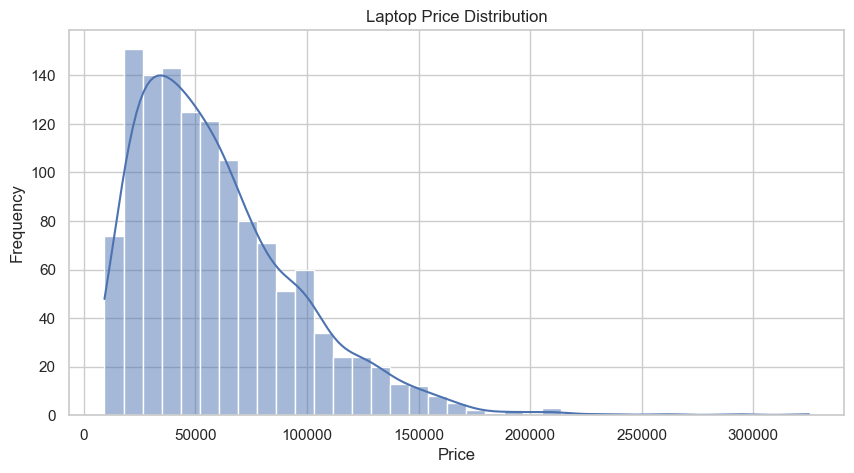

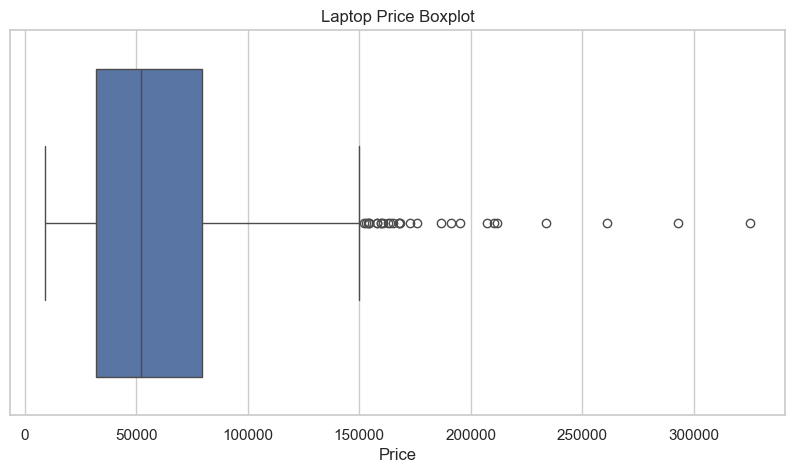

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean["Price"], kde=True)
plt.title("Laptop Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x=df_clean["Price"])
plt.title("Laptop Price Boxplot")
plt.xlabel("Price")
plt.show()


## 7. EDA — Numerical Features


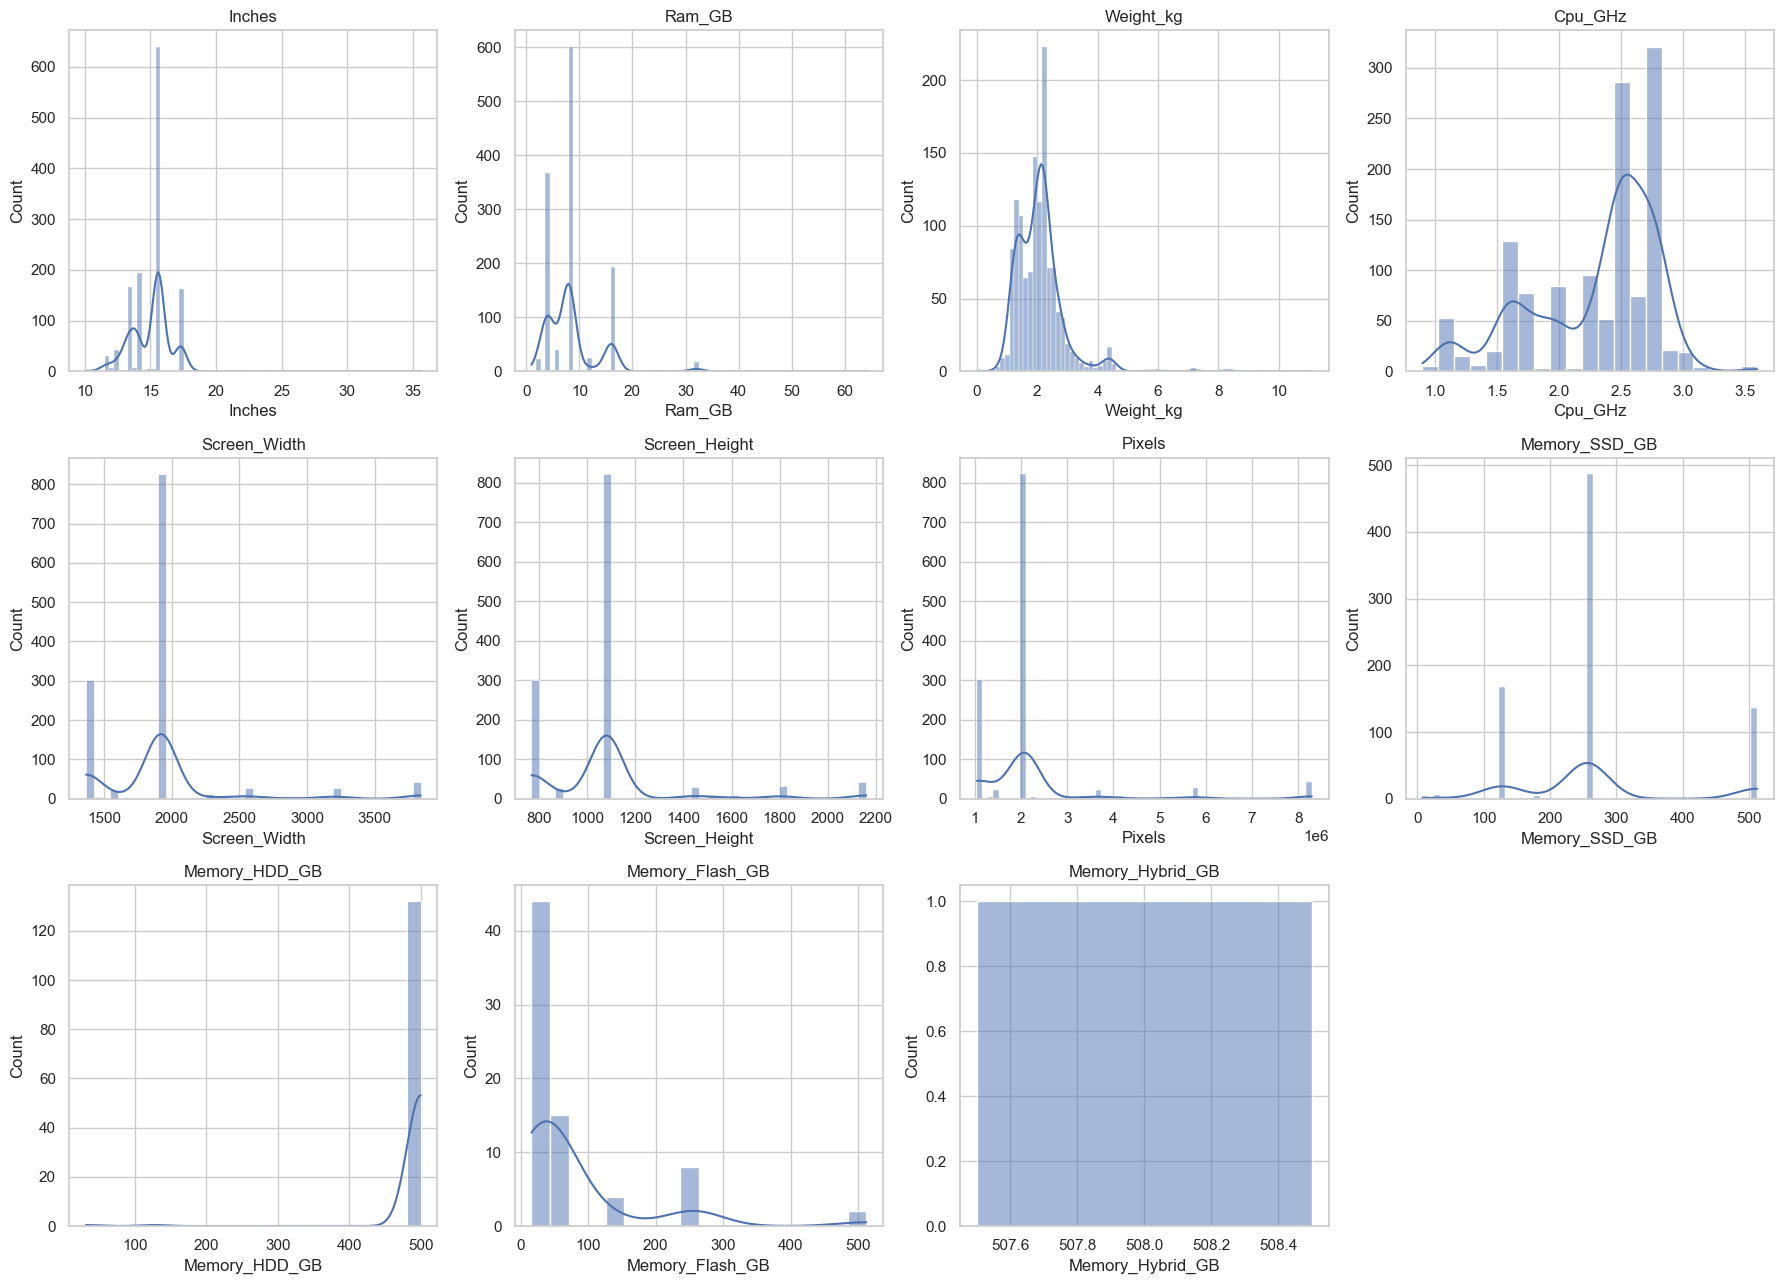

In [13]:
numeric_eda = [
    "Inches", "Ram_GB", "Weight_kg", "Cpu_GHz",
    "Screen_Width", "Screen_Height", "Pixels",
    "Memory_SSD_GB", "Memory_HDD_GB",
    "Memory_Flash_GB", "Memory_Hybrid_GB"
]

numeric_eda = [c for c in numeric_eda if c in df_clean.columns]

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes = axes.flatten()

for ax, col in zip(axes, numeric_eda):
    sns.histplot(df_clean[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)

for ax in axes[len(numeric_eda):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## 8. EDA — Categorical Features


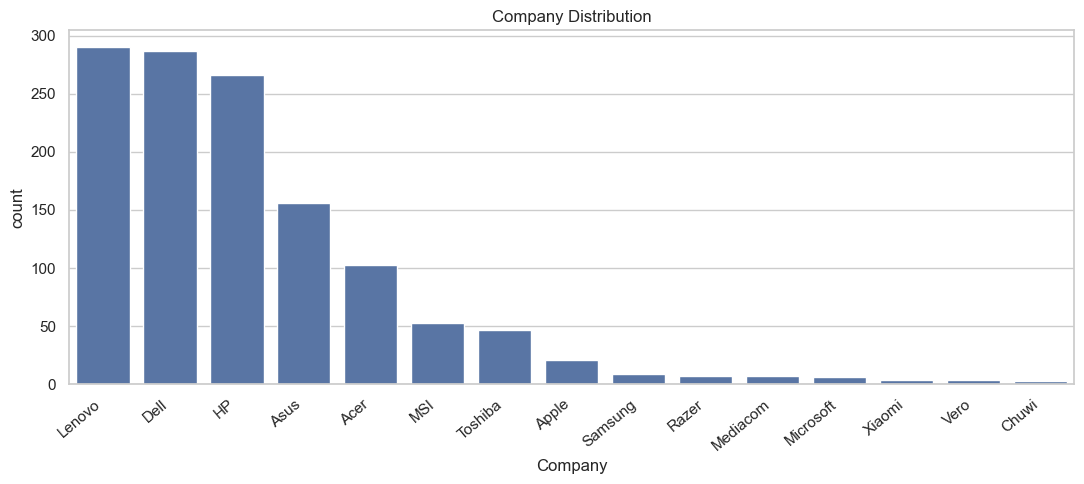

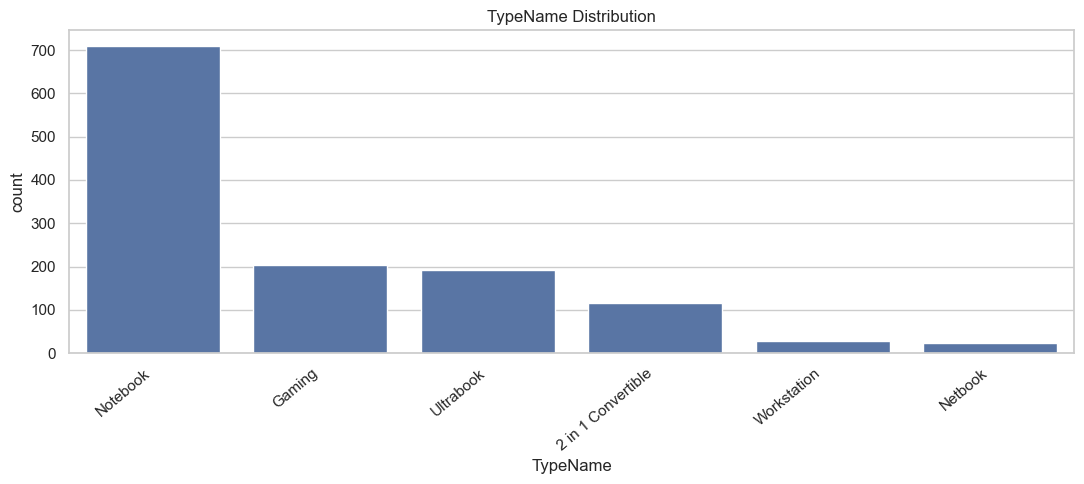

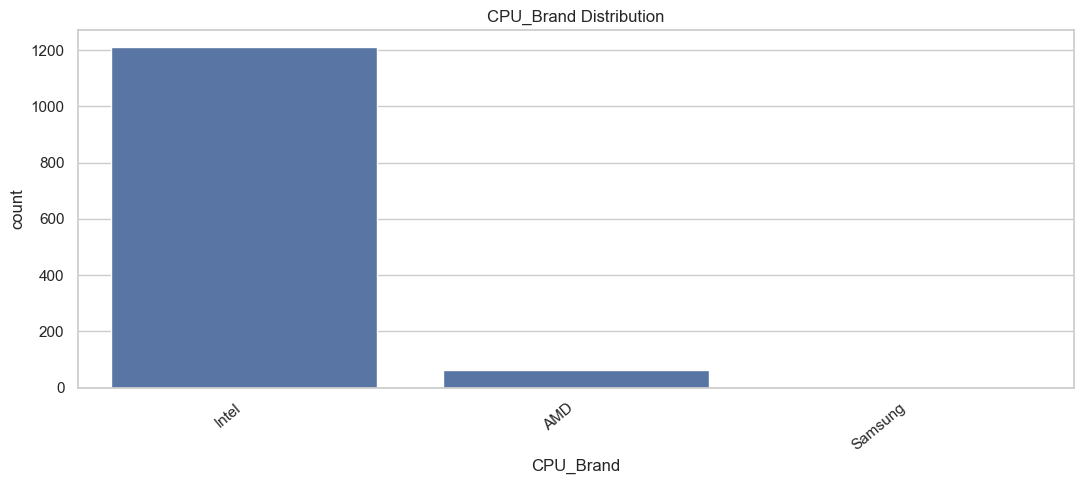

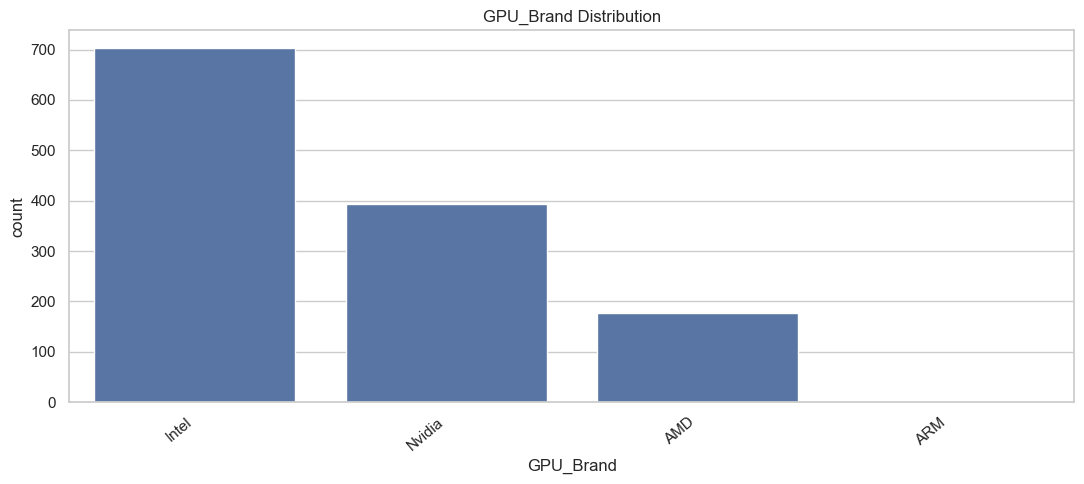

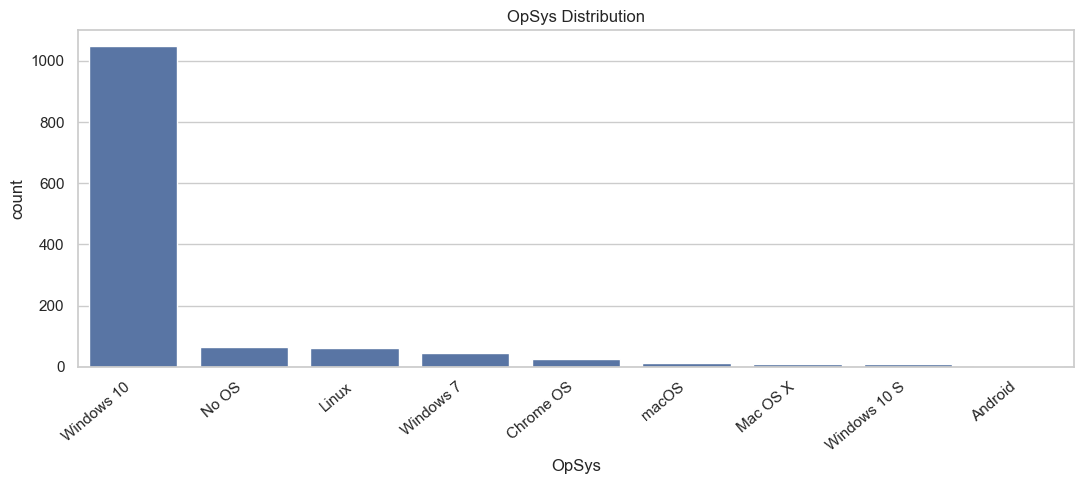

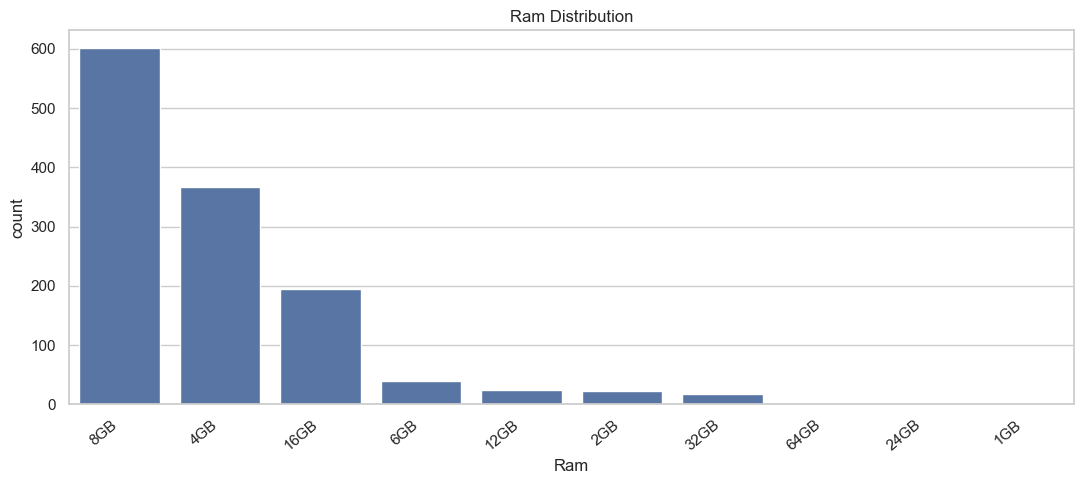

In [14]:
categorical_eda = [
    "Company", "TypeName", "CPU_Brand",
    "GPU_Brand", "OpSys", "Ram"
]

for col in categorical_eda:
    plt.figure(figsize=(11,5))
    order = df_clean[col].value_counts().head(15).index
    sns.countplot(data=df_clean, x=col, order=order)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=40, ha="right")
    plt.tight_layout()
    plt.show()


## 9. Data Analysis — Price by Company


,count,mean,median
Company,,,
Razer,7,178282.491429,154458.7200
LG,3,111834.720000,111834.7200
MSI,53,91814.548891,85194.7200
Google,3,89386.080000,83063.5200
Microsoft,6,85903.788000,83622.9600
Apple,21,83340.499886,71378.6832
Huawei,2,75870.720000,75870.7200
Samsung,9,75308.320000,87858.7200
Toshiba,47,66747.370213,64468.8000


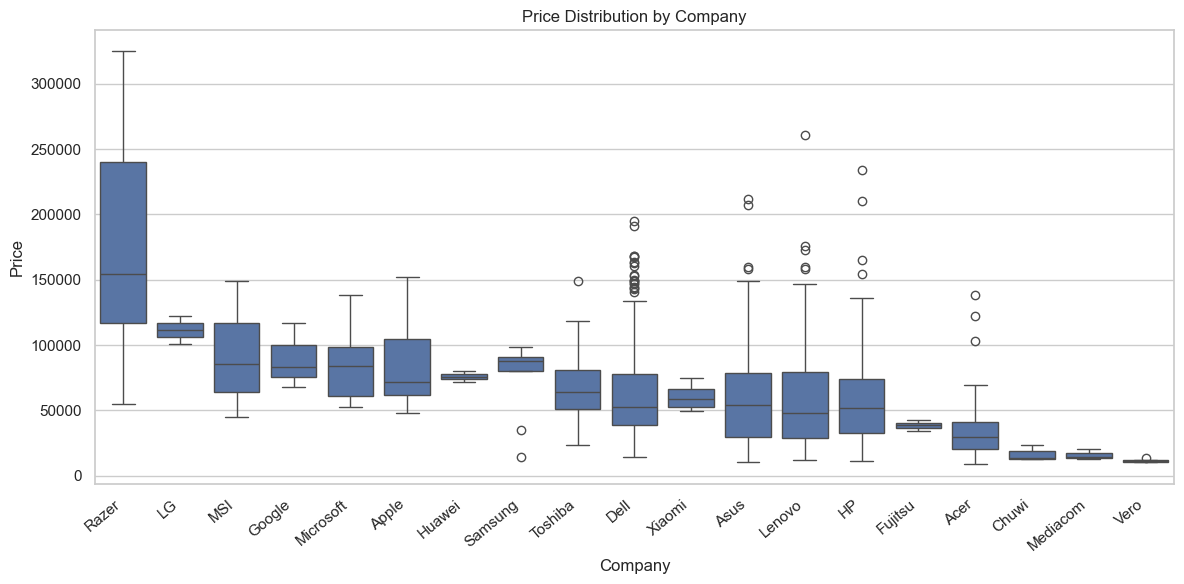

In [15]:
company_price = (
    df_clean.groupby("Company")["Price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

display(company_price)

plt.figure(figsize=(12,6))
order = company_price.index
sns.boxplot(data=df_clean, x="Company", y="Price", order=order)
plt.xticks(rotation=40, ha="right")
plt.title("Price Distribution by Company")
plt.tight_layout()
plt.show()


## 10. Data Analysis — RAM vs Price


,count,mean,median
Ram_GB,,,
1.0,1,53226.720000,53226.7200
2.0,22,14756.743636,12893.7600
4.0,367,30552.912235,26533.4400
6.0,40,32826.420720,30795.8400
8.0,601,63160.787525,58554.7200
12.0,25,66037.277952,66546.7200
16.0,194,103158.266994,100352.8800
24.0,3,117553.440000,126912.9600
32.0,17,181849.215812,167691.8736


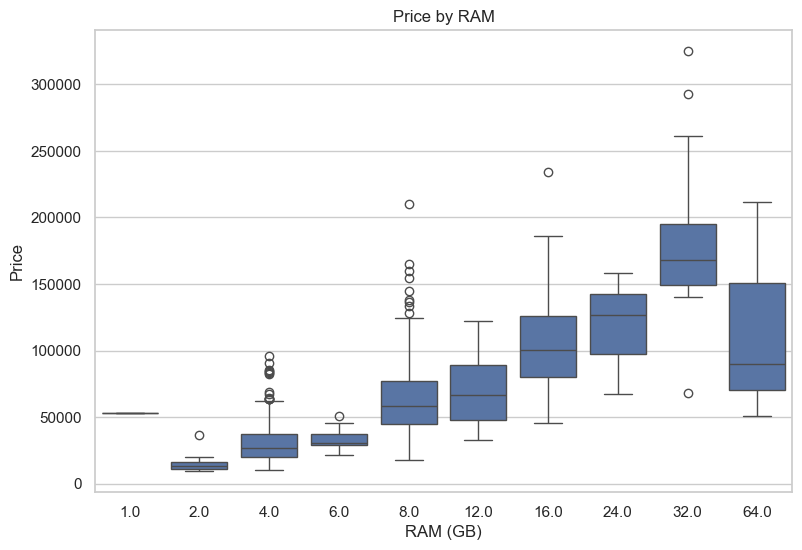

In [16]:
ram_price = df_clean.groupby("Ram_GB")["Price"].agg(["count", "mean", "median"])
display(ram_price)

plt.figure(figsize=(9,6))
sns.boxplot(data=df_clean, x="Ram_GB", y="Price")
plt.title("Price by RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Price")
plt.show()


## 11. Data Analysis — Laptop Type


,count,mean,median
TypeName,,,
Workstation,29,121497.525683,110017.8720
Gaming,203,92204.328662,79215.1056
Ultrabook,191,82926.038073,79866.7200
2 in 1 Convertible,116,68186.738110,63882.7200
Notebook,710,41545.173052,36896.1336
Netbook,24,34884.858000,18514.8000


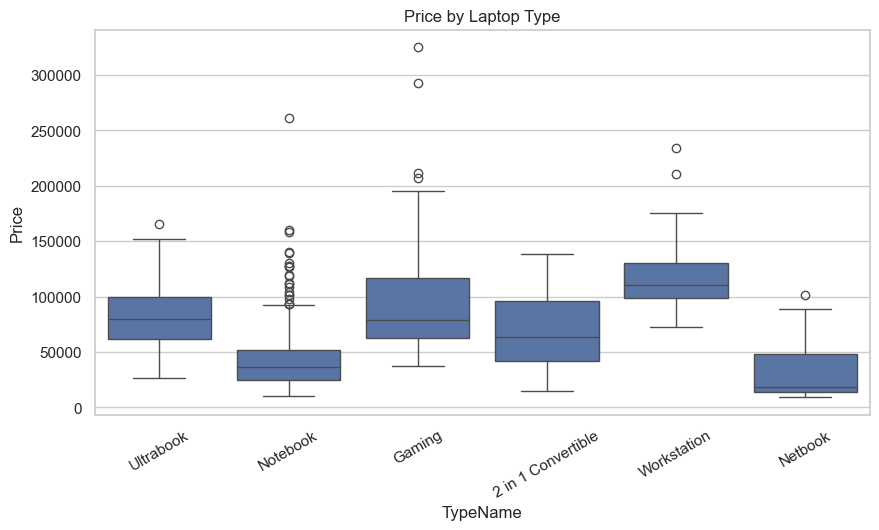

In [17]:
type_price = (
    df_clean.groupby("TypeName")["Price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

display(type_price)

plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean, x="TypeName", y="Price")
plt.xticks(rotation=30)
plt.title("Price by Laptop Type")
plt.show()


## 12. Correlation Analysis


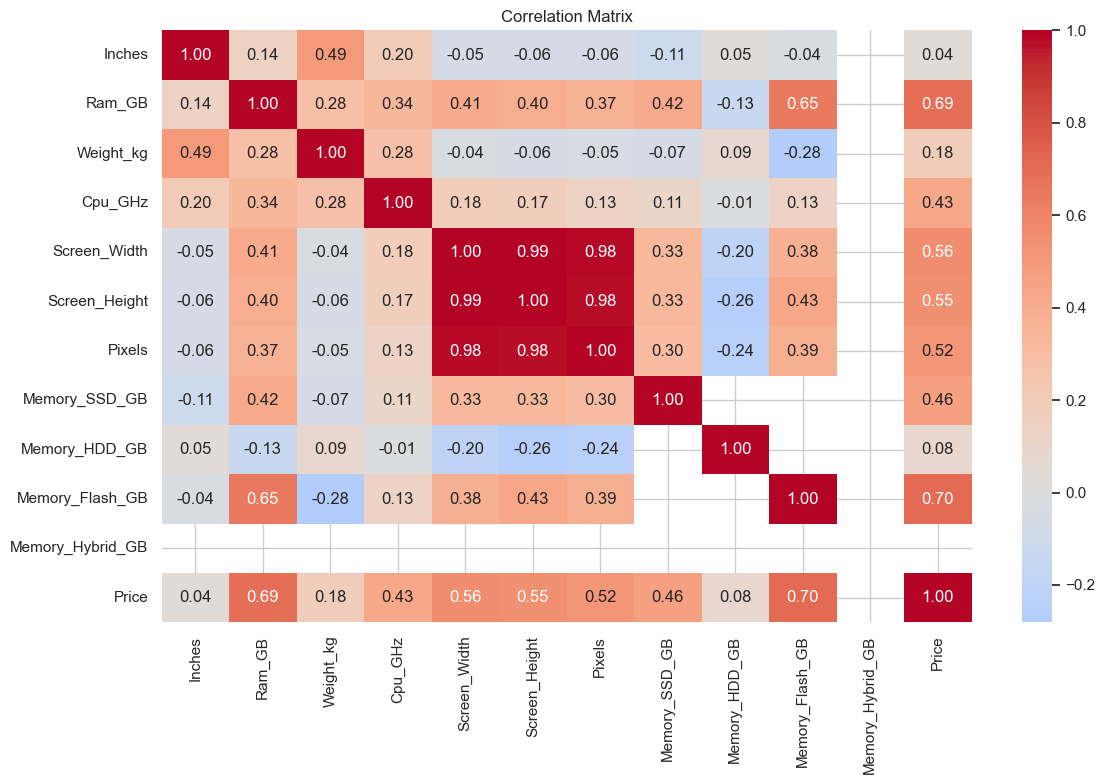

Correlation with Price:


,correlation_with_price
Price,1.000000
Memory_Flash_GB,0.704259
Ram_GB,0.685648
Screen_Width,0.557556
Screen_Height,0.554069
Pixels,0.516728
Memory_SSD_GB,0.461011
Cpu_GHz,0.428969
Weight_kg,0.175928
Memory_HDD_GB,0.082267


In [18]:
corr_cols = [
    "Inches", "Ram_GB", "Weight_kg", "Cpu_GHz",
    "Screen_Width", "Screen_Height", "Pixels",
    "Memory_SSD_GB", "Memory_HDD_GB",
    "Memory_Flash_GB", "Memory_Hybrid_GB", "Price"
]

corr_cols = [c for c in corr_cols if c in df_clean.columns]

plt.figure(figsize=(12,8))
sns.heatmap(
    df_clean[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("Correlation with Price:")
display(
    df_clean[corr_cols]
    .corr()["Price"]
    .sort_values(ascending=False)
    .to_frame("correlation_with_price")
)


## 13. Prepare Features and Target


In [19]:
# Raw high-cardinality specification columns are excluded because
# engineered versions capture their useful information more cleanly.
drop_cols = [
    "Price",
    "ScreenResolution",
    "Cpu",
    "Gpu",
    "Memory"
]

X = df_clean.drop(columns=drop_cols, errors="ignore")
y = df_clean["Price"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())


X shape: (1273, 20)
y shape: (1273,)


,Company,TypeName,Inches,Ram,OpSys,Weight,Ram_GB,Weight_kg,Cpu_GHz,Screen_Width,Screen_Height,Pixels,Touchscreen,IPS,CPU_Brand,GPU_Brand,Memory_SSD_GB,Memory_HDD_GB,Memory_Flash_GB,Memory_Hybrid_GB
0,Apple,Ultrabook,13.3,8GB,macOS,1.37kg,8.0,1.37,2.3,2560.0,1600.0,4096000.0,0,1,Intel,Intel,128.0,NaN,NaN,NaN
1,Apple,Ultrabook,13.3,8GB,macOS,1.34kg,8.0,1.34,1.8,1440.0,900.0,1296000.0,0,0,Intel,Intel,NaN,NaN,128.0,NaN
2,HP,Notebook,15.6,8GB,No OS,1.86kg,8.0,1.86,2.5,1920.0,1080.0,2073600.0,0,0,Intel,Intel,256.0,NaN,NaN,NaN
3,Apple,Ultrabook,15.4,16GB,macOS,1.83kg,16.0,1.83,2.7,2880.0,1800.0,5184000.0,0,1,Intel,AMD,512.0,NaN,NaN,NaN
4,Apple,Ultrabook,13.3,8GB,macOS,1.37kg,8.0,1.37,3.1,2560.0,1600.0,4096000.0,0,1,Intel,Intel,256.0,NaN,NaN,NaN


## 14. Train / Test Split


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)


Training: (1018, 20)
Testing : (255, 20)


## 15. Preprocessing Pipeline


In [21]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['Inches', 'Ram_GB', 'Weight_kg', 'Cpu_GHz', 'Screen_Width', 'Screen_Height', 'Pixels', 'Touchscreen', 'IPS', 'Memory_SSD_GB', 'Memory_HDD_GB', 'Memory_Flash_GB', 'Memory_Hybrid_GB']
Categorical features: ['Company', 'TypeName', 'Ram', 'OpSys', 'Weight', 'CPU_Brand', 'GPU_Brand']


## 16. Regression Models


In [22]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(alpha=1.0),

    "KNN": KNeighborsRegressor(n_neighbors=5),

    "SVR": SVR(kernel="rbf"),

    "Decision Tree": DecisionTreeRegressor(
        random_state=1
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=1,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=1,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostRegressor(
        random_state=1,
        n_estimators=200
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=1
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        random_state=1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=1,
        n_jobs=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=False,
        random_seed=1
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=1,
        verbosity=-1,
        n_jobs=-1
    )
}


## 17. Train and Evaluate All Models


In [23]:
results = {}
fitted_models = {}

for name, model in tqdm(models.items()):

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    test_mape = mean_absolute_percentage_error(y_test, test_pred)

    results[name] = {
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Test MAPE": test_mape
    }

    fitted_models[name] = pipe

    print("\n" + "="*70)
    print(name)
    print("="*70)
    print("Test MAE :", round(test_mae, 2))
    print("Test RMSE:", round(test_rmse, 2))
    print("Test R²  :", round(test_r2, 4))
    print("Test MAPE:", round(test_mape * 100, 2), "%")

results_df = pd.DataFrame(results).T.sort_values(
    "Test RMSE",
    ascending=True
)

display(results_df.round(4))


 15%|████████████▊                                                                      | 2/13 [00:00<00:00, 13.88it/s]


Linear Regression
Test MAE : 11428.88
Test RMSE: 17644.0
Test R²  : 0.7854
Test MAPE: 19.81 %

Ridge
Test MAE : 11830.72
Test RMSE: 18034.11
Test R²  : 0.7758
Test MAPE: 20.19 %

KNN
Test MAE : 11849.35
Test RMSE: 19794.84
Test R²  : 0.7299
Test MAPE: 19.25 %


 31%|█████████████████████████▌                                                         | 4/13 [00:02<00:07,  1.19it/s]


SVR
Test MAE : 28886.16
Test RMSE: 39760.8
Test R²  : -0.0898
Test MAPE: 56.94 %

Decision Tree
Test MAE : 12688.84
Test RMSE: 20796.85
Test R²  : 0.7019
Test MAPE: 20.83 %


 46%|██████████████████████████████████████▎                                            | 6/13 [00:03<00:04,  1.46it/s]

...

 92%|███████████████████████████████████████████████████████████████████████████▋      | 12/13 [00:57<00:07,  7.63s/it]


CatBoost
Test MAE : 11148.72
Test RMSE: 17125.34
Test R²  : 0.7978
Test MAPE: 18.9 %


100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [01:02<00:00,  4.79s/it]


LightGBM
Test MAE : 9788.45
Test RMSE: 16014.07
Test R²  : 0.8232
Test MAPE: 16.1 %


,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Test MAPE
XGBoost,6261.6411,10061.5499,8326.2368,15499.6507,0.9496,0.8344,0.1690
LightGBM,5774.5625,9788.4491,9631.4873,16014.0740,0.9326,0.8232,0.1610
Random Forest,4026.7782,9361.1675,6303.2623,16309.5314,0.9711,0.8166,0.1506
Gradient Boosting,8968.4350,11217.9576,11881.0504,16579.3955,0.8974,0.8105,0.2005
Hist Gradient Boosting,6453.7354,10092.8617,10553.1822,16601.9448,0.9191,0.8100,0.1675
CatBoost,8514.3251,11148.7168,11448.9596,17125.3363,0.9047,0.7978,0.1890
Linear Regression,8936.0546,11428.8758,13051.9393,17643.9988,0.8762,0.7854,0.1981
Ridge,9697.5003,11830.7162,13684.4372,18034.1111,0.8639,0.7758,0.2019
Extra Trees,524.4184,10955.2162,1890.4239,18581.7891,0.9974,0.7620,0.1658
KNN,9205.2256,11849.3546,14517.4483,19794.8419,0.8468,0.7299,0.1925


## 18. Actual vs Predicted — Best Baseline Model


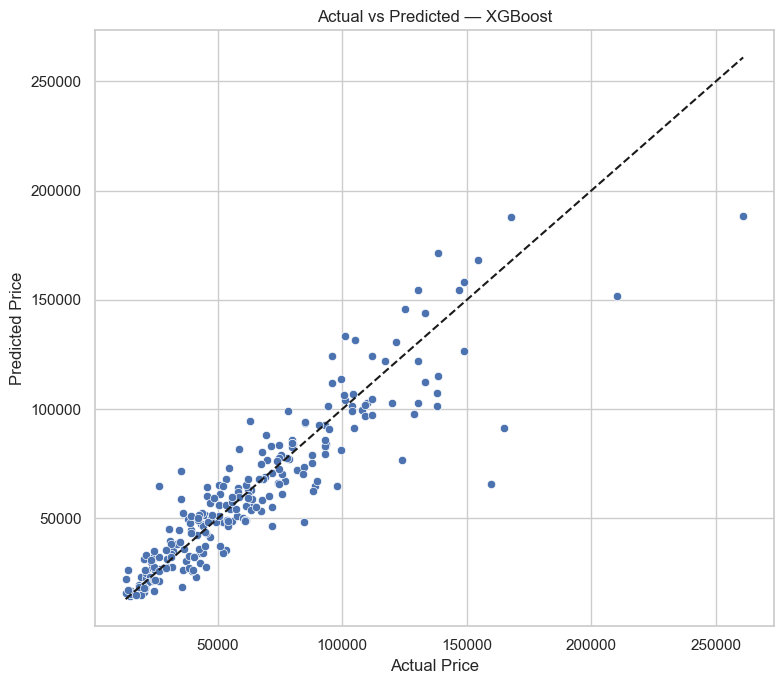

In [24]:
best_baseline_name = results_df["Test RMSE"].idxmin()
best_baseline = fitted_models[best_baseline_name]

baseline_pred = best_baseline.predict(X_test)

plt.figure(figsize=(8,7))
sns.scatterplot(x=y_test, y=baseline_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted — {best_baseline_name}")

min_value = min(y_test.min(), baseline_pred.min())
max_value = max(y_test.max(), baseline_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], "k--")

plt.tight_layout()
plt.show()


## 19. Residual Analysis


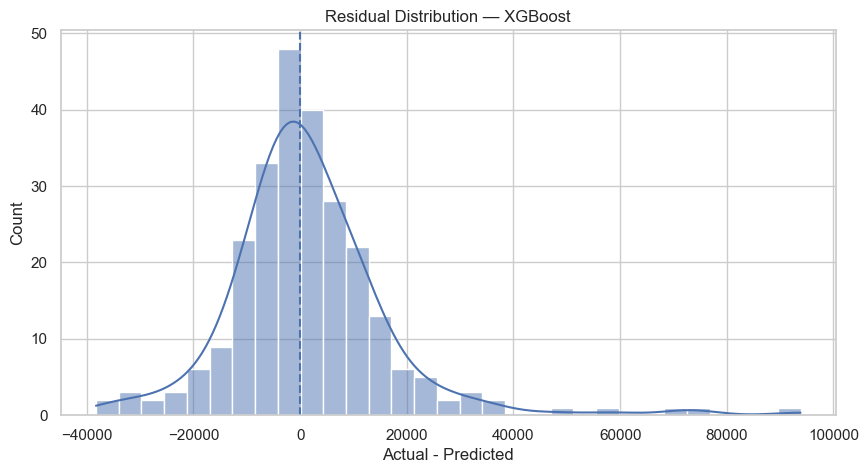

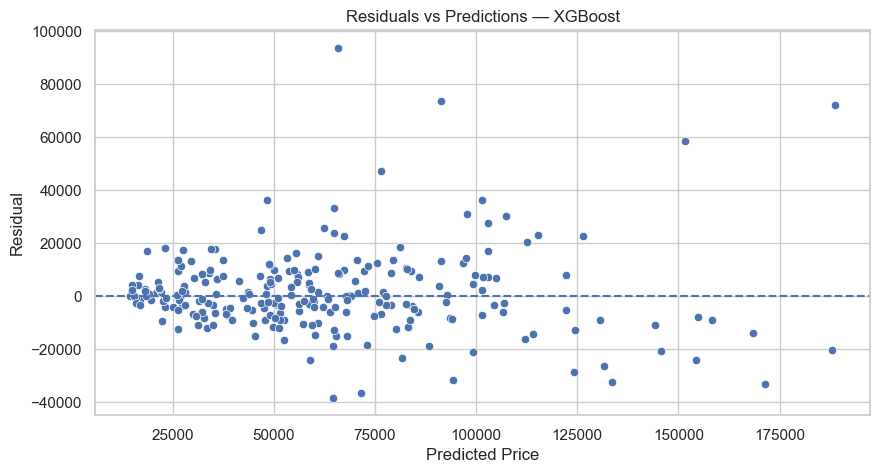

In [25]:
residuals = y_test - baseline_pred

plt.figure(figsize=(10,5))
sns.histplot(residuals, kde=True)
plt.axvline(0, linestyle="--")
plt.title(f"Residual Distribution — {best_baseline_name}")
plt.xlabel("Actual - Predicted")
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(x=baseline_pred, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title(f"Residuals vs Predictions — {best_baseline_name}")
plt.show()


## 20. Model Comparison


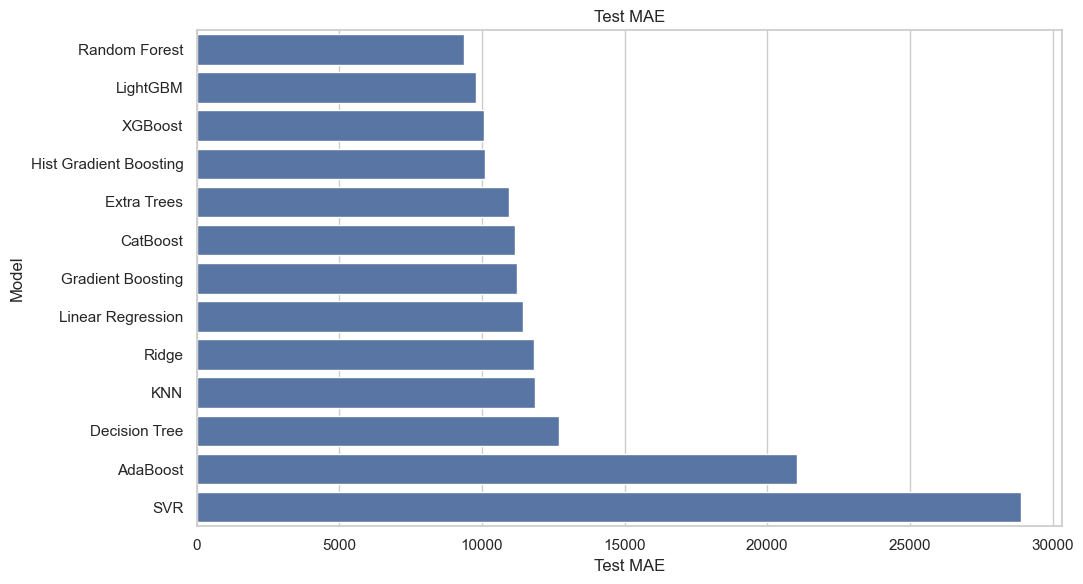

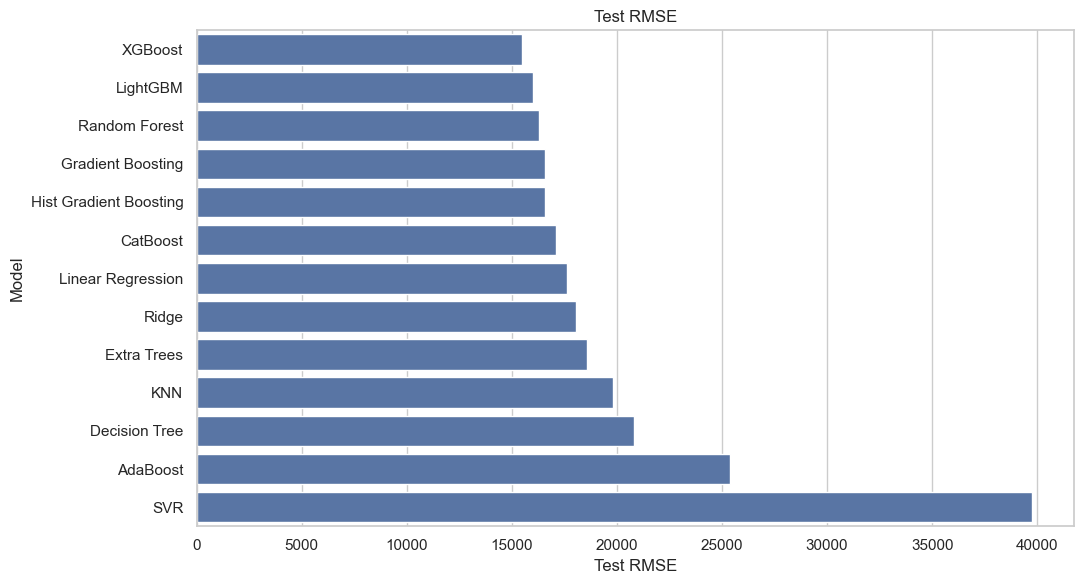

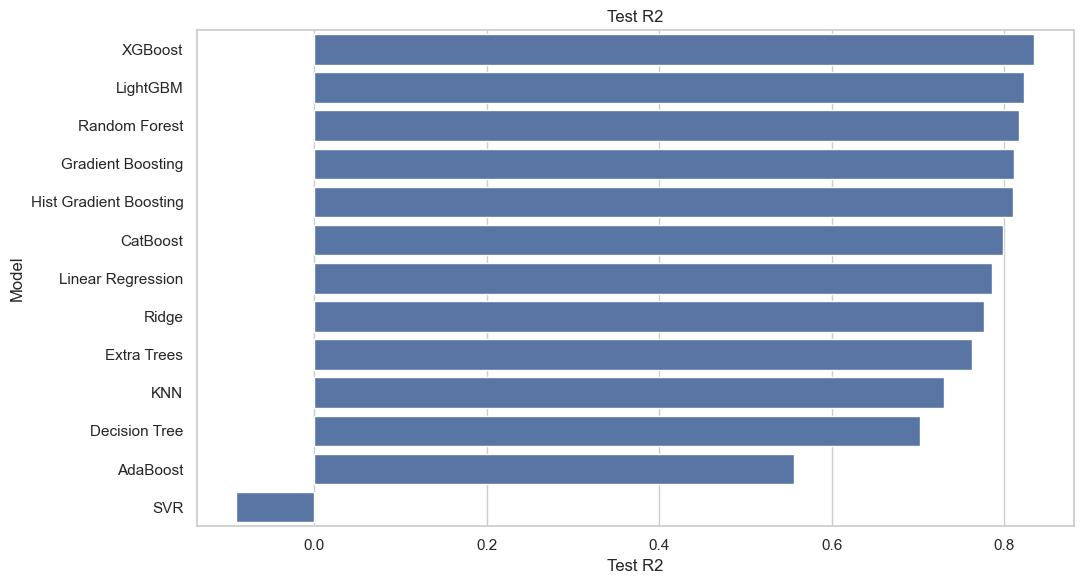

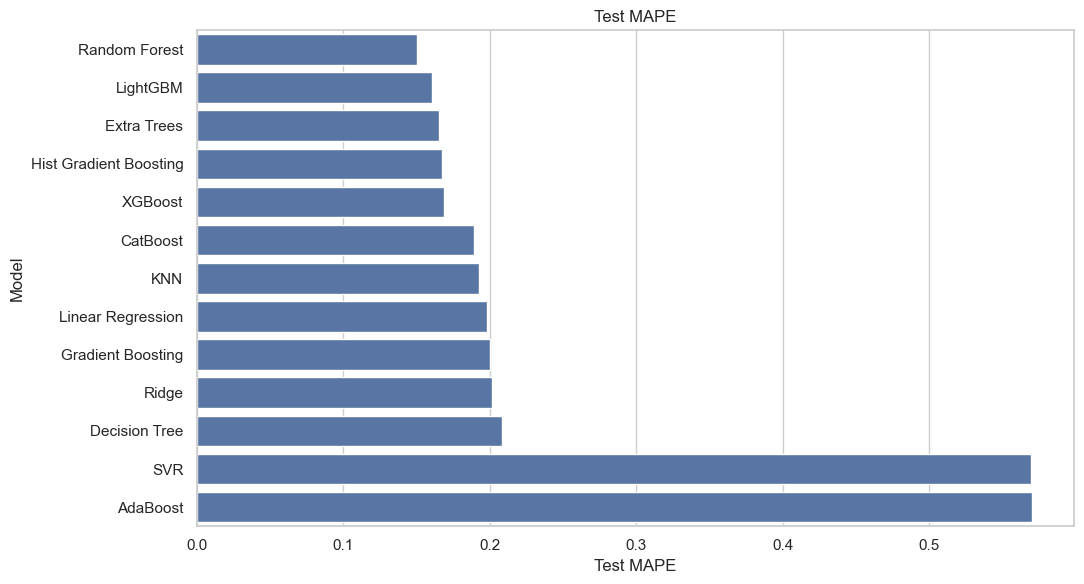

In [26]:
for metric in ["Test MAE", "Test RMSE", "Test R2", "Test MAPE"]:

    ascending = metric != "Test R2"
    order = results_df[metric].sort_values(
        ascending=ascending
    ).index

    plt.figure(figsize=(11,6))
    sns.barplot(
        x=results_df.loc[order, metric].values,
        y=order
    )
    plt.title(metric)
    plt.xlabel(metric)
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()


# 21. GridSearchCV

Grid search is performed only on the training set.

We use **5-fold cross-validation** and optimize **negative RMSE**, so the selected model minimizes prediction error.


In [27]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_models = {

    "Ridge": (
        Ridge(),
        {
            "model__alpha": [0.01, 0.1, 1, 10, 100]
        }
    ),

    "KNN": (
        KNeighborsRegressor(),
        {
            "model__n_neighbors": [3, 5, 7, 9, 15],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        }
    ),

    "Decision Tree": (
        DecisionTreeRegressor(random_state=1),
        {
            "model__max_depth": [None, 5, 10, 15, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    ),

    "Random Forest": (
        RandomForestRegressor(random_state=1, n_jobs=-1),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5],
            "model__max_features": ["sqrt", 1.0]
        }
    ),

    "Extra Trees": (
        ExtraTreesRegressor(random_state=1, n_jobs=-1),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5],
            "model__max_features": ["sqrt", 1.0]
        }
    ),

    "Gradient Boosting": (
        GradientBoostingRegressor(random_state=1),
        {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3, 5]
        }
    ),

    "XGBoost": (
        XGBRegressor(
            objective="reg:squarederror",
            random_state=1,
            n_jobs=-1
        ),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    ),

    "LightGBM": (
        LGBMRegressor(
            random_state=1,
            verbosity=-1,
            n_jobs=-1
        ),
        {
            "model__n_estimators": [200, 400],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__num_leaves": [15, 31, 63],
            "model__max_depth": [-1, 5, 10]
        }
    )
}


In [28]:
grid_results = {}
best_estimators = {}

for name, (model, param_grid) in grid_models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    print("\n" + "="*80)
    print("Grid Search:", name)
    print("="*80)

    grid.fit(X_train, y_train)

    best_estimators[name] = grid.best_estimator_

    pred = grid.best_estimator_.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = mean_absolute_percentage_error(y_test, pred)

    grid_results[name] = {
        "Best CV RMSE": -grid.best_score_,
        "Test MAE": mae,
        "Test RMSE": rmse,
        "Test R2": r2,
        "Test MAPE": mape,
        "Best Params": grid.best_params_
    }

    print("Best CV RMSE:", round(-grid.best_score_, 2))
    print("Test RMSE:", round(rmse, 2))
    print("Test R2:", round(r2, 4))
    print("Best Parameters:")
    print(grid.best_params_)

grid_results_df = pd.DataFrame(grid_results).T.sort_values(
    "Test RMSE",
    ascending=True
)

display(grid_results_df)



Grid Search: Ridge
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV RMSE: 18635.47
Test RMSE: 18034.11
Test R2: 0.7758
Best Parameters:
{'model__alpha': 1}

Grid Search: KNN
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV RMSE: 17779.79
Test RMSE: 19352.89
Test R2: 0.7418
Best Parameters:
{'model__n_neighbors': 7, 'model__p': 1, 'model__weights': 'distance'}

Grid Search: Decision Tree
Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best CV RMSE: 20387.09
Test RMSE: 18593.72
Test R2: 0.7617
Best Parameters:
{'model__max_depth': 15, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}

Grid Search: Random Forest
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV RMSE: 16562.75
Test RMSE: 16800.6
Test R2: 0.8054
Best Parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 400}

Grid Search: Extra Trees
Fitting 5 folds for each of 24 candi

,Best CV RMSE,Test MAE,Test RMSE,Test R2,Test MAPE,Best Params
XGBoost,17153.583158,10138.028502,15778.201411,0.82839,0.169497,"{'model__colsample_bytree': 0.8, 'model__learn..."
LightGBM,16766.762315,9864.25558,15910.996659,0.825489,0.160693,"{'model__learning_rate': 0.05, 'model__max_dep..."
Gradient Boosting,17716.015656,10844.007891,16221.888458,0.818602,0.189179,"{'model__learning_rate': 0.1, 'model__max_dept..."
Random Forest,16562.750946,9763.633406,16800.600782,0.805429,0.156125,"{'model__max_depth': None, 'model__max_feature..."
Extra Trees,16634.597529,10235.207973,17273.441666,0.794323,0.157788,"{'model__max_depth': None, 'model__max_feature..."
Ridge,18635.474237,11830.716244,18034.111104,0.775809,0.201921,{'model__alpha': 1}
Decision Tree,20387.088194,12439.677904,18593.720065,0.76168,0.212425,"{'model__max_depth': 15, 'model__min_samples_l..."
KNN,17779.786453,11047.997031,19352.887626,0.741821,0.168843,"{'model__n_neighbors': 7, 'model__p': 1, 'mode..."


## 22. Final Tuned Model


In [29]:
best_model_name = grid_results_df["Test RMSE"].idxmin()
best_model = best_estimators[best_model_name]

final_pred = best_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)
final_mape = mean_absolute_percentage_error(y_test, final_pred)

print("Best tuned model:", best_model_name)
print("MAE :", round(final_mae, 2))
print("RMSE:", round(final_rmse, 2))
print("R²  :", round(final_r2, 4))
print("MAPE:", round(final_mape * 100, 2), "%")


Best tuned model: XGBoost
MAE : 10138.03
RMSE: 15778.2
R²  : 0.8284
MAPE: 16.95 %


## 23. Final Actual vs Predicted


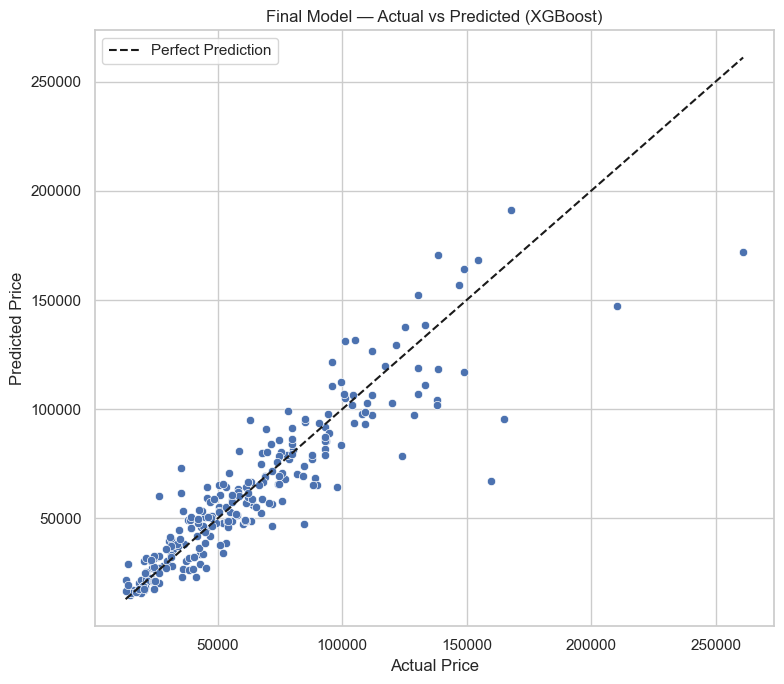

In [30]:
plt.figure(figsize=(8,7))
sns.scatterplot(x=y_test, y=final_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Final Model — Actual vs Predicted ({best_model_name})")

min_value = min(y_test.min(), final_pred.min())
max_value = max(y_test.max(), final_pred.max())
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "k--",
    label="Perfect Prediction"
)

plt.legend()
plt.tight_layout()
plt.show()


## 24. Feature Importance


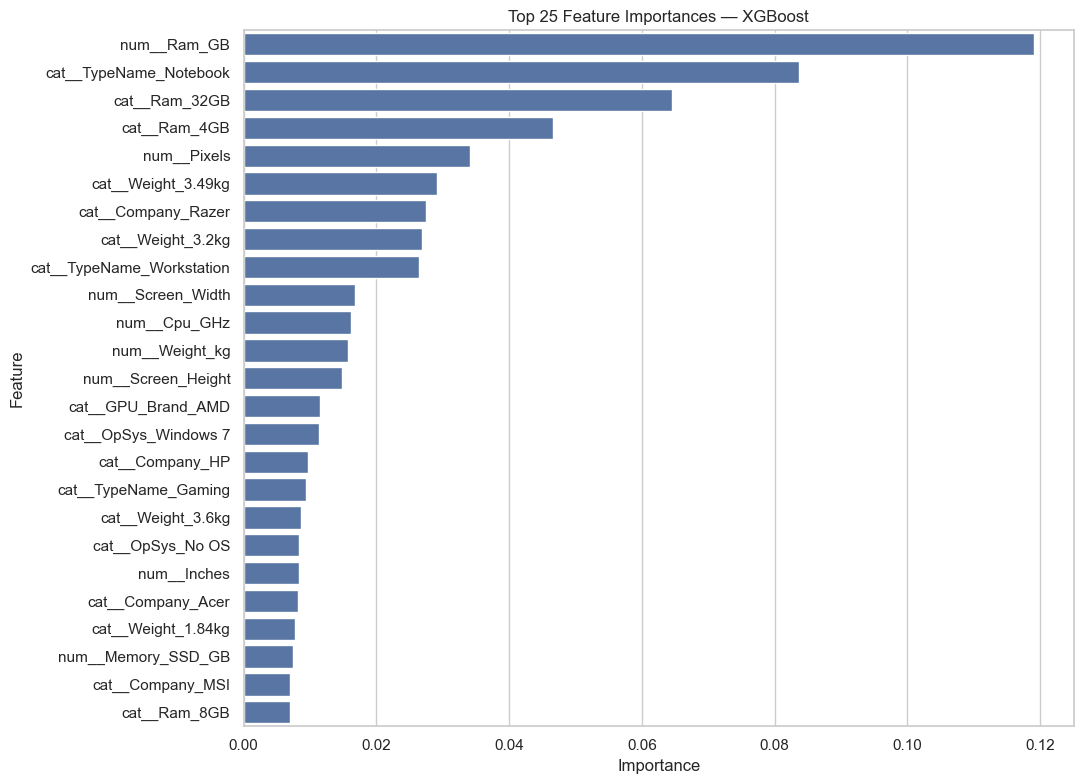

,importance
num__Ram_GB,0.119126
cat__TypeName_Notebook,0.083641
cat__Ram_32GB,0.064504
cat__Ram_4GB,0.046598
num__Pixels,0.034078
cat__Weight_3.49kg,0.029076
cat__Company_Razer,0.027552
cat__Weight_3.2kg,0.026848
cat__TypeName_Workstation,0.026482
num__Screen_Width,0.016736


In [31]:
model_step = best_model.named_steps["model"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

if hasattr(model_step, "feature_importances_"):

    importance = pd.Series(
        model_step.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False).head(25)

    plt.figure(figsize=(11,8))
    sns.barplot(x=importance.values, y=importance.index)
    plt.title(f"Top 25 Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    display(importance.to_frame("importance"))

elif hasattr(model_step, "coef_"):

    importance = pd.Series(
        np.abs(model_step.coef_),
        index=feature_names
    ).sort_values(ascending=False).head(25)

    plt.figure(figsize=(11,8))
    sns.barplot(x=importance.values, y=importance.index)
    plt.title(f"Top 25 Absolute Coefficients — {best_model_name}")
    plt.xlabel("Absolute coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    display(importance.to_frame("absolute_coefficient"))


# 25. Optional Classification Version

If your instructor specifically requires the **classification code you supplied**, we can convert the continuous `Price` target into three classes:

- Low
- Medium
- High

using the 33rd and 66th percentiles.

Then your classification models (`LogisticRegression`, `KNN`, `SVC`, `RandomForestClassifier`, `XGBClassifier`, etc.) and metrics (`Accuracy`, `Precision`, `Recall`, `F1`, ROC-AUC) become appropriate.

The main project above is still the more natural solution because the original target is an actual numeric price.


In [32]:
# Optional: create price categories
q1 = df_clean["Price"].quantile(1/3)
q2 = df_clean["Price"].quantile(2/3)

df_class = df_clean.copy()

df_class["Price_Category"] = pd.cut(
    df_class["Price"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Low", "Medium", "High"]
)

display(df_class["Price_Category"].value_counts())
display(
    df_class.groupby("Price_Category", observed=True)["Price"]
    .agg(["count", "min", "mean", "median", "max"])
)


Price_Category
Low       425
High      425
Medium    423
Name: count, dtype: int64

,count,min,mean,median,max
Price_Category,,,,,
Low,425,9270.72,25724.124322,25840.80,38378.6496
Medium,423,38468.16,52208.951081,52161.12,67718.8800
High,425,67772.16,101897.910991,94572.00,324954.7200


# 26. Conclusion

The project follows a complete professional ML workflow:

**Data → Cleaning → EDA → Analysis → Feature Engineering → Preprocessing → ML Models → Evaluation → Grid Search → Final Model**

### Key modeling lesson
The original `Price` column is continuous, therefore **regression is the correct formulation**.

The supplied classification code can be reused after creating `Price_Category`, but it should not be used directly to predict the exact numeric price.
